In [110]:
import numpy as np  # for fast array and mathematical operations
import pandas as pd # pandas to handle tabular data (Dataframes)
import matplotlib.pyplot as plt # generating plots n charts 
import seaborn as sns
from sklearn.datasets import fetch_openml
from scipy.io import arff

In [111]:

# Load the Adult Income dataset from OpenML
adult = fetch_openml(data_id=1590, as_frame=True, parser='auto')
df_adult = adult.frame
print(f'Shape of the Dataset :{df_adult.shape}')
print(f'Dataset Display :')
display(df_adult)
print('--Basic Information about the dataset--')
print(df_adult.info())
# Separating the Numeric cols and Categorical Cols 
num_cols=df_adult.select_dtypes(include=['int64']).columns.tolist()
cat_cols=df_adult.select_dtypes(exclude=['int64']).columns.tolist()






Shape of the Dataset :(48842, 15)
Dataset Display :


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


--Basic Information about the dataset--
<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB
None


In [112]:
# Check null Values 
missing_data=df_adult.isnull().sum()
print(missing_data)

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64


# Analysis from the above information :
1. We have 48842 rows of data and 15 columns.
2. There are 9 categorical columns and 6 numeric columns
3. We can see there are some missing /null values in few features like native-country,occupation and workclass.
4. So we will have to check how many missing values we have and how to handle it.

In [113]:
#Lets check Statistical description of the numeric columns
print('--- Statistical Information of Numeric Columns ---')
df_adult.describe().T


--- Statistical Information of Numeric Columns ---


,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [114]:
# Our Target column - Class 
df_adult['class'].value_counts()

class
<=50K    37155
>50K     11687
Name: count, dtype: int64

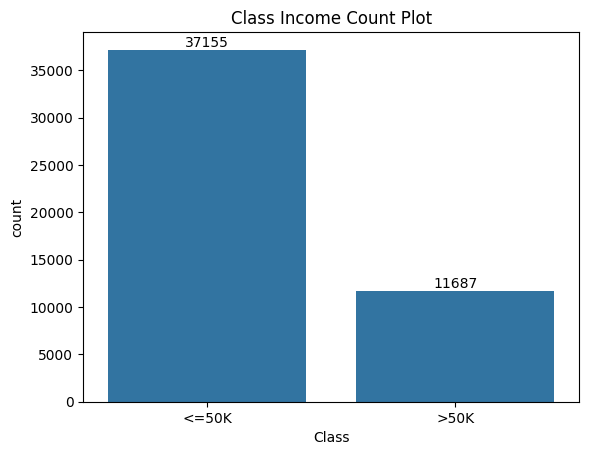

In [115]:
# Count Plot for our Target column for a better visual understanding 

ax = sns.countplot(x=df_adult['class'], data=df_adult)
for container in ax.containers:
    ax.bar_label(container)
    plt.title('Class Income Count Plot')
    plt.xlabel('Class')
    plt.show()


What inference we get from the above description :
1. Age column : Ranges between 17-90 years of age with a mean of 38.6 , which indicates most of the working class adults fall in the early 40's age group 
2. Features like capital gain , capital loss has a min value 0 and max value 99999 , these need to be Standardized 
3. Our class (Target Column) is highly imbalanced -> Need to take care of this while data pre processing or else our ML model will be biased


# Exploratory Data Analysis :
- We will now visualize our Numeric and Categorical Data for better insights. 
- Histograms n boxplots will be created for Numeric data to check for outliers and data distribution 
- For categorical data we will create count plots to understand which category dominates 


The skewness of Age: 0.56


Text(0, 0.5, 'Frequency')

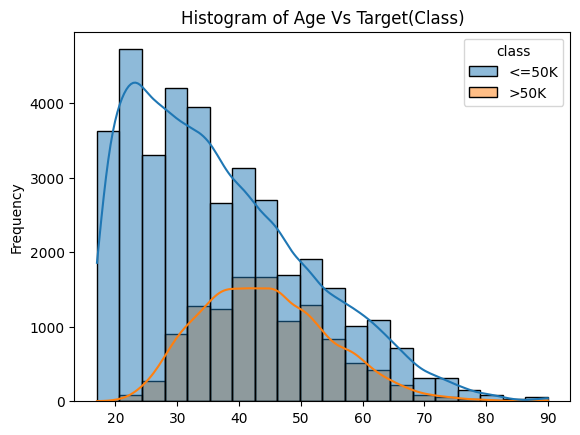

In [116]:
# Histogram Plotting 
from scipy.stats import skew
plt.Figure(figsize=(15,12))
sns.histplot(data=df_adult,x=df_adult['age'],hue=df_adult['class'],kde=True,bins=20)
plt.title('Histogram of Age Vs Target(Class)')
#skewness
skewness_age = skew(df_adult['age'])
print(f"The skewness of Age: {skewness_age :.2f}")
plt.xlabel('')
plt.ylabel('Frequency')





Age Vs Target (Class) :
1. Income of age group 20-35 is mostly <=50
2. In the middle agwe group 30-40s we see significantly higher income. 
3. In older age group ,50-70s we see a decline in the income for both the classes .
4. The histogram depicts positive right skewed 
5. Age alone can not be a strong distinguishing factor for the class of income as the incomes overlap 

Correlation Heatmap 

<Axes: >

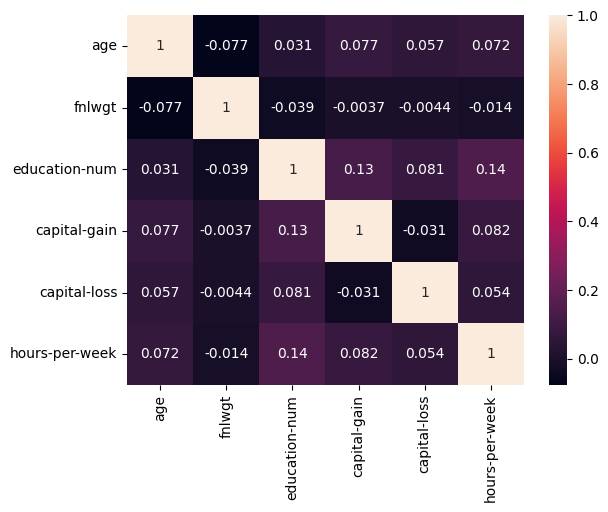

In [117]:
correlation_matrix=df_adult[num_cols].corr()
sns.heatmap(correlation_matrix,annot=True)


- From the above heatmap we see that there is not issue of multi-colinearity.
- Infact the features have a very weak corelation overall. 


Categorical  Column Analysis 

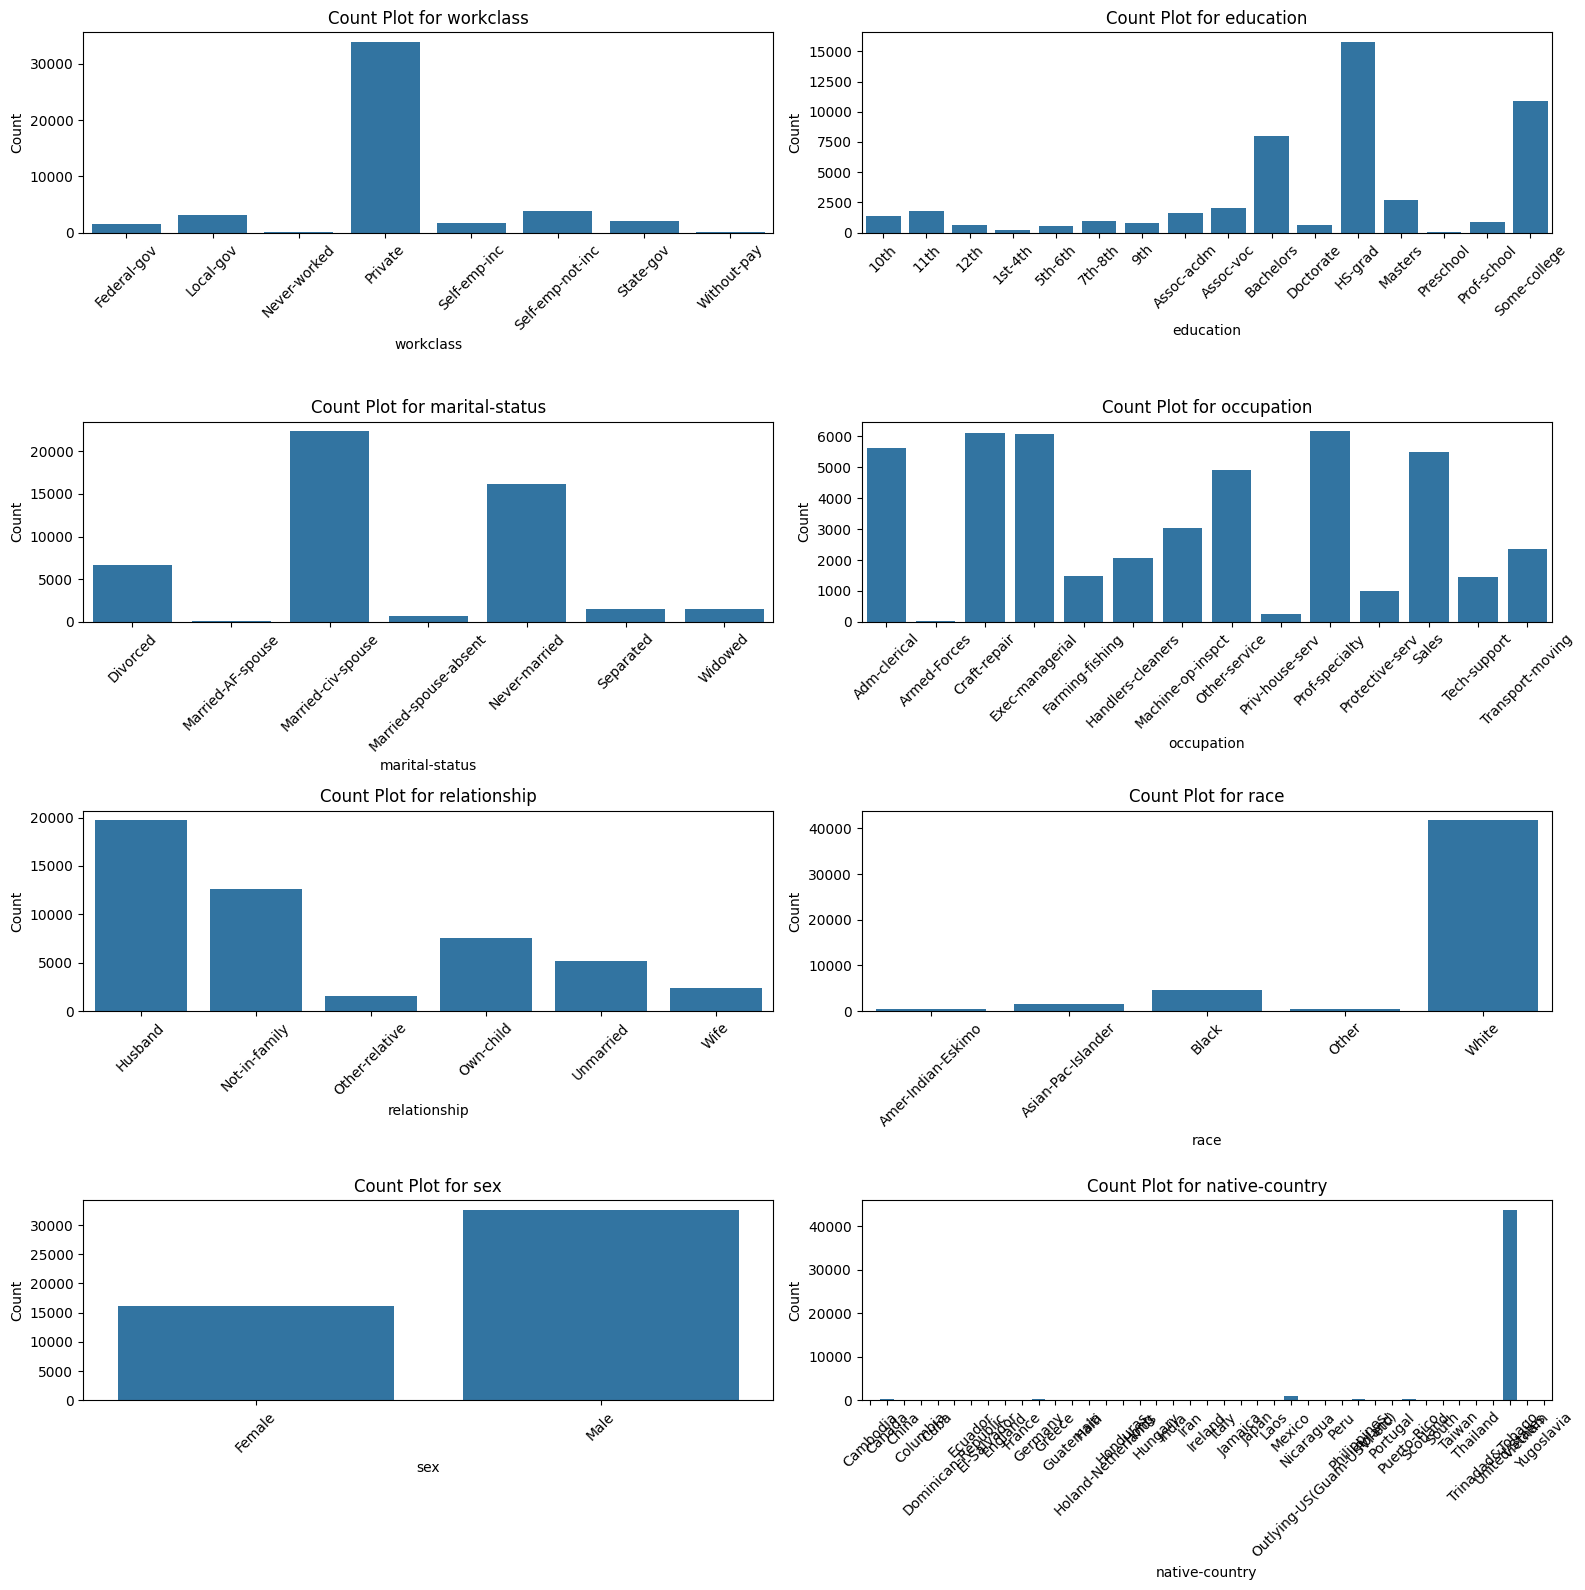

In [118]:
# Building count plot for our categorical features.
cat_features=df_adult.drop(columns=['class','age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']).columns.tolist()

fig, axes = plt.subplots(4, 2, figsize=(16, 16)) # 4 rows, 2 columns
axes = axes.flatten() # Flatten to 1D for easy looping

for i, col in enumerate(cat_features):
    sns.countplot(x=col, data=df_adult, ax=axes[i])
    axes[i].set_title(f'Count Plot for {col}')
    axes[i].set_ylabel('Count')
    # Tilt/Rotate the x-axis labels
    axes[i].tick_params(axis='x', rotation=45) # Tilt labels by 45 degrees

plt.tight_layout() # Adjusts spacing
plt.show()

In [119]:
df_adult['native-country'].value_counts()

native-country
United-States                 43832
Mexico                          951
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Guatemala                        88
Poland                           87
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Greece                           49
Nicaragua                        49
Peru                             46
Ecuador      

In [120]:
import pandas as pd
import plotly.express as px


# Count occurrences of each country
country_counts = df_adult['native-country'].value_counts().reset_index()
country_counts.columns = ['native-country', 'count']

# Create choropleth map
fig = px.choropleth(
    country_counts,
    locations='native-country',
    locationmode='country names',  # important
    color='count',
    color_continuous_scale='Blues',
    title='Count by Country'
)

fig.show()

C:\Users\ali59\AppData\Local\Temp\ipykernel_20604\3146345127.py:10: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


# Feature Engineering and Data Pre-processing

In [121]:

# Separate our independent variables (X) from the target (y)

X = df_adult.drop(['class'], axis=1)
y = df_adult['class']

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)  # Y - class had values<=50,>=50 , this code will convert it into 1,0 valyes that the model can understand.


# Split immediately to prevent data leakage!
# stratify=y guarantees the rare class >50k cases are proportionally split.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
     

In [122]:
# We have to handle null categorical columns - Occupation, workclass and native country 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
# 1. Numerical Pipeline (Impute missing)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# 2. Categorical Pipeline (Impute missing -> OneHotEncode)
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Combine them into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[

    ('cat', cat_pipeline, cat_features)
], remainder='passthrough') # pass through 'is_high_glucose', 'hypertension', etc

# 4. The Master Pipeline!
# (Custom Features -> Clean/Encode -> Model)
from xgboost import XGBClassifier
full_pipeline = Pipeline([

    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
])
     

# Train the entire pipeline using the training data
full_pipeline.fit(X_train, y_train)

# Ask the pipeline to make predictions on the unseen test data
y_pred_base = full_pipeline.predict(X_test)





-- Baseline Model Classification Report --
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      7431
           1       0.78      0.66      0.71      2338

    accuracy                           0.87      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.87      0.87      9769



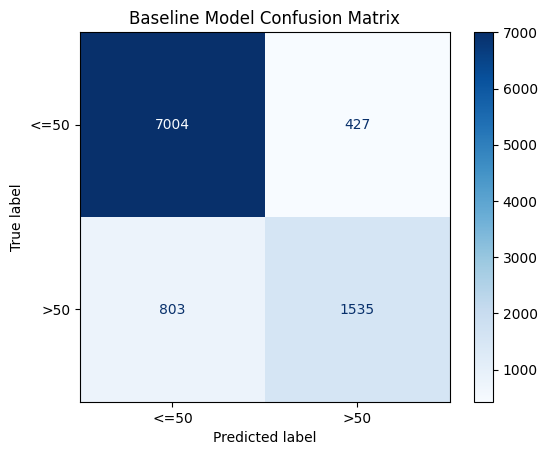

In [123]:
# Lets Evaluate the model 
from sklearn.metrics import classification_report,ConfusionMatrixDisplay,confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
print("-- Baseline Model Classification Report --")
print(f'{classification_report(y_test,y_pred_base)}')

# Create Confusion Matrix to visually see how he model performed 
cm=confusion_matrix(y_test,y_pred_base)
# plot confusion matrix
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['<=50','>50'])
disp.plot(cmap='Blues')
plt.title('Baseline Model Confusion Matrix')
plt.grid(False) # Turn off the seaborn grid lines for a cleaner matrix look
plt.show()



In [124]:
results = []

#  Model 1 : Baseline XGBoast Classifier
results.append({
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test,y_pred_base),
    'Precision': precision_score(y_test,y_pred_base),
    'Recall': recall_score(y_test,y_pred_base),
    'F1 Score': f1_score(y_test,y_pred_base)
})

Baseline Model Evaluation :
- Accuracy of our baseline model is 87%
- The precision and recall for the class 1(>50) is quite less ,ie ,78% and 66 % respectively. Our Target column (class) is highly imbalanced and hence we will use techniques to handle the imbalance and then review our model on its accuracy ,precision and recall.

# Handling Class Imbalance :
1. Iteration A : Scale_pos_weights is used to handle the imbalance dataset 
2. Iteration B: Hyperparameter Tuning - Use GridSearch / RandomizedSearch

In [125]:
# claculate ration of class y=0/ class y=1 
balance_ratio=sum(y_train==0)/sum(y_train==1)
print(f"Calculated scale_pos_weight: {balance_ratio:.2f}")

tuned_pipeline = Pipeline([

    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(scale_pos_weight=balance_ratio,max_depth=3,learning_rate=0.01,n_estimators=100,eval_metric='logloss', random_state=42))
])

# Train the imbalance-aware model
tuned_pipeline.fit(X_train, y_train)

# Make new predictions
y_pred_tuned = tuned_pipeline.predict(X_test)

Calculated scale_pos_weight: 3.18


-- Baseline Model Classification Report --
              precision    recall  f1-score   support

           0       0.95      0.72      0.82      7431
           1       0.49      0.87      0.63      2338

    accuracy                           0.75      9769
   macro avg       0.72      0.79      0.72      9769
weighted avg       0.84      0.75      0.77      9769



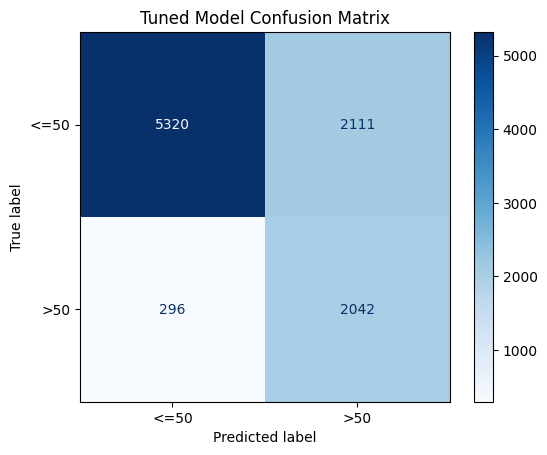

In [126]:
# Lets Evaluate the model 
from sklearn.metrics import classification_report,ConfusionMatrixDisplay,confusion_matrix
print("-- Baseline Model Classification Report --")
print(f'{classification_report(y_test,y_pred_tuned)}')

# Create Confusion Matrix to visually see how he model performed 
cm=confusion_matrix(y_test,y_pred_tuned)
# plot confusion matrix
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['<=50','>50'])
disp.plot(cmap='Blues')
plt.title('Tuned Model Confusion Matrix')
plt.grid(False) # Turn off the seaborn grid lines for a cleaner matrix look
plt.show()

In [127]:
#  Model 2 : Weighted Class Model
results.append({
    'Model': 'Weighted Class',
    'Accuracy': accuracy_score(y_test,y_pred_tuned),
    'Precision': precision_score(y_test,y_pred_tuned),
    'Recall': recall_score(y_test,y_pred_tuned),
    'F1 Score': f1_score(y_test,y_pred_tuned)
})

In [128]:
from sklearn.model_selection import GridSearchCV
weighted_pipeline = Pipeline([

    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(scale_pos_weight=balance_ratio,eval_metric='logloss', random_state=42))
])

param_grid = {
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__n_estimators': [100, 200]
}

grid = GridSearchCV(
    estimator=weighted_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    error_score='raise'
)

grid.fit(X_train, y_train)

print("\n🏆 Grid Search Completed!")
print(f"Best Hyperparameters Found: {grid.best_params_}")





🏆 Grid Search Completed!
Best Hyperparameters Found: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 200}


--- Final Optimized (Weighted GridSearch) Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.83      0.88      7431
           1       0.61      0.86      0.71      2338

    accuracy                           0.84      9769
   macro avg       0.78      0.84      0.80      9769
weighted avg       0.87      0.84      0.84      9769



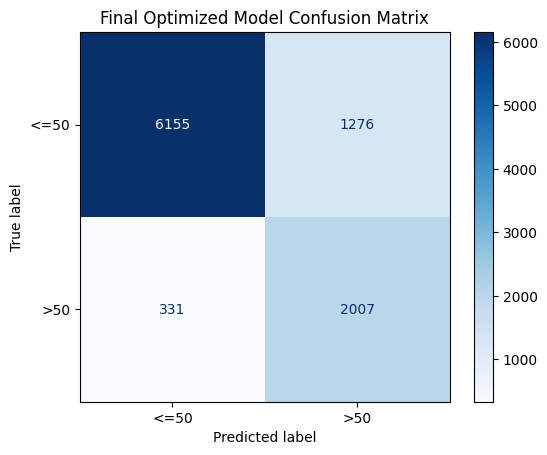

In [129]:
#extract the optimized pipeline 
best_pipeline =grid.best_estimator_
y_pred_GSCV=best_pipeline.predict(X_test)

print("--- Final Optimized (Weighted GridSearch) Classification Report ---")
print(classification_report(y_test, y_pred_GSCV))

# Create Confusion Matrix to visually see how he model performed 
cm=confusion_matrix(y_test,y_pred_GSCV)
# plot confusion matrix
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['<=50','>50'])
disp.plot(cmap='Blues')
plt.title('Final Optimized Model Confusion Matrix')
plt.grid(False) # Turn off the seaborn grid lines for a cleaner matrix look
plt.show()

In [130]:
# Model 3 : GridSearchCV(Hyper parameter Tuning)
results.append({
    'Model': 'GridSearchCV',
    'Accuracy': accuracy_score(y_test, y_pred_GSCV),
    'Precision': precision_score(y_test, y_pred_GSCV),
    'Recall': recall_score(y_test, y_pred_GSCV),
    'F1 Score': f1_score(y_test, y_pred_GSCV)
})

In [131]:
results_df = pd.DataFrame(results)
print(results_df)

            Model  Accuracy  Precision    Recall  F1 Score
0         XGBoost  0.874092   0.782365  0.656544  0.713953
1  Weighted Class  0.753608   0.491693  0.873396  0.629179
2    GridSearchCV  0.835500   0.611331  0.858426  0.714108


Conclusion :
- We did hyper parameter tuning using GridsearchCV to choose the best parameters 
- We could significantly increase the Recall score but precision dropped a bit 
- Our f1 score that we got from the baseline model was 71% , later when we handled the class imbalance using Scale_pos_weights recall increases but precision and F1 score further decreases. 
- We are aiming for a balance of Precison to recall ratio 
- We try hyper parameter tuning aand use GridSearchCV - we get a precision of 61%,recall of 86% and f1 score 71% .